In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
from glob import glob
from tqdm.auto import tqdm
import h5py
import librosa
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

In [5]:
from HARMES.config import base_path

In [6]:
dataset_folder = base_path  + "/"

In [22]:
def get_labels(rec_path):
    try:
        res =  glob(rec_path + "/*[0-9][0-9][0-9][0-9][0-9].csv")[0]
        return pd.read_csv(res)
    except:
        print(rec_path)
        raise(Exception())

def get_watch(rec_path):
    return glob(rec_path + "/recording*_[0-9][0-9].csv")[0]
            

def get_puck(rec_path):
    return glob(rec_path + "/*_merged.csv")[0]

def get_audio(rec_path):
    x = glob(rec_path + "/*H5.h5")[0]
    return h5py.File(x)


def get_participants(base_path):
    return glob(base_path + "/*")

def get_recordings(part_path):
    return glob(part_path + "/*")

In [8]:

def clean_label_df(label_df):
    label_df["ts_sync"] = (label_df.Time - label_df.Time.iloc[0]) * 1000
    label_df = label_df[~label_df["Description"].str.contains("deleted", na=False)]
    label_df = label_df.iloc[1:]
    return label_df


def handle_split_recordings(rec1, rec2):
    label_df1 = get_labels(rec1)
    label_df1 = clean_label_df(label_df1)
    label_df2 = get_labels(rec2)
    task_list = pd.read_csv(glob(rec1 + "/*TASKLIST.csv")[0])

    # Find the checkpoint, at which the split happened, by looking at the first 5 entries of the second recording's labels
    seq = label_df2[label_df2.Type == "end"].Description.to_list()[:4]
    tl = task_list.TASKS.to_list()
    ind = [i for i in range(len(tl)) if tl[i:i + len(seq)] == seq][0]
    # The last recording should end with these 5 (which were conducted before the checkpoint)
    end_seq = tl[ind - 5:ind - 1]
    labels_1 = label_df1[label_df1.Type == "end"].Description.to_list()
    indices = label_df1[label_df1.Type == "end"].index
    # Match the sequence to an index
    ind = [i + len(end_seq) - 1 for i in range(len(labels_1)) if labels_1[i:i + len(end_seq)] == end_seq][0]

    # calculate timestamp for end of first recording.
    last_line1 = label_df1.loc[indices[ind]]
    last_ts = last_line1.ts_sync + 1000
    label_df1 = label_df1[label_df1.ts_sync < last_ts]
    return label_df1, label_df2

In [9]:

def read_last_ts(rec):
    fp = get_watch(rec)
    with open(fp,"rb") as f:
        f.seek(-2,2)
        while f.read(1)!=b"\n":
            f.seek(-2,1)
        return f.readline().decode().strip().split(",")[-1]

In [10]:
durations = []
durations_unlabeled = []
activities = []
for part_folder in sorted(glob(dataset_folder + "*")):
    part = part_folder[-2:]
    for rec_folder in sorted(glob(part_folder + "/*")):
        label_dfs = []
        rec = rec_folder[-4:]
        if rec_folder[-1] == "4":
            durations.append([part, rec, float(read_last_ts(rec_folder)) / 1000 / 60, False])
            continue
        if os.path.isdir(rec_folder + "/" + rec + "01"):
            print("double:", rec_folder)
            rec1 = rec_folder + "/" + rec + "01"
            rec2 = rec_folder + "/" + rec + "02"
            label_dfs = handle_split_recordings(rec1, rec2)
            duration = label_dfs[0].iloc[-1].ts_sync
            duration += float(read_last_ts(rec2))
        else:
            label_dfs = [get_labels(rec_folder)]
            duration = read_last_ts(rec_folder)
        for label_df in label_dfs:
            
            label_df["ts_sync"] = (label_df.Time - label_df.Time.iloc[0]) * 1000
            
            all_labels = label_df.Description.iloc[1:].unique()
            all_labels = [label for label in all_labels if "deleted" not in label]
            for label in all_labels:
                l_df = label_df[label_df.Description == label]
                l_start = l_df[l_df.Type == "start"]
                l_stop = l_df[l_df.Type == "end"]
                for i, (start, stop) in enumerate(zip(l_start.ts_sync.to_list(), l_stop.ts_sync.to_list())):
                    if label != "RECORD":
                        activities.append([part, rec, (stop - start) / 1000, label])
        durations.append([part, rec, float(duration) / 1000 / 60, True])

double: AudioDS/Dataset/Records/05/0501
double: AudioDS/Dataset/Records/09/0903
double: AudioDS/Dataset/Records/13/1301
double: AudioDS/Dataset/Records/13/1302
double: AudioDS/Dataset/Records/14/1401
double: AudioDS/Dataset/Records/15/1501
double: AudioDS/Dataset/Records/18/1802
double: AudioDS/Dataset/Records/19/1902
double: AudioDS/Dataset/Records/20/2001


In [11]:
act_df = pd.DataFrame(activities, columns=["Participant", "Recording", "Duration", "Activity"])
dur_df =  pd.DataFrame(durations, columns=["Participant", "Recording", "Duration", "Labeled"])
lab_dur_df = dur_df[dur_df.Labeled == True]
sns.set(style="whitegrid")
dur_df.groupby(["Participant"])["Duration"].sum().mean(), dur_df[dur_df.Labeled == False].groupby(["Participant"])["Duration"].sum().sum() / 60, act_df[act_df.Duration < 0]


(np.float64(241.61368041468464),
 np.float64(19.633930833333334),
 Empty DataFrame
 Columns: [Participant, Recording, Duration, Activity]
 Index: [])

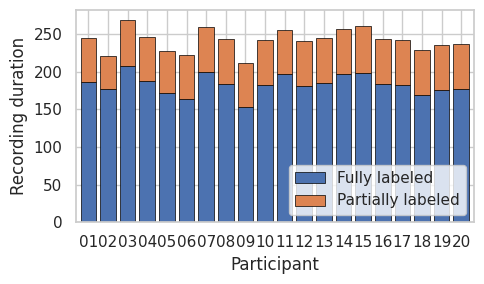

In [12]:
plt.figure(figsize=(5,3))

# aggregate by participant AND labeled flag
agg = dur_df.groupby(["Participant", "Labeled"])["Duration"].sum().unstack(fill_value=0)

# plot stacked bars
agg.columns = agg.columns.astype(str)
agg = agg[["True", "False"]]

agg.plot(kind="bar", stacked=True, ax=plt.gca(), width=0.8, linewidth=0.5, edgecolor="black")

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Fully labeled", "Partially labeled"], title="", loc="lower right")
#, bbox_to_anchor=(0.7,0.3))

plt.ylabel("Recording duration")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("duration_per_part.pdf")

In [13]:
dur_df[dur_df.Labeled == True].Duration.sum() / 60,dur_df.Duration.sum() / 60

(np.float64(60.9039626382282), np.float64(80.53789347156155))

In [14]:
act_df.groupby("Activity").sum()["Duration"] /60

Activity
Brushing teeth                 241.356464
Cleaning out the dishwasher    176.849719
Cleaning table                 129.352539
Cream hands                     68.902887
Cutting vegetables             197.267015
Disinfecting hands              39.074368
Drinking                        94.520073
Floor cleaning                 335.200842
Making tea                     327.026028
Putting away the dishes        197.965367
Vacuum Cleaning                319.042288
Washing dishes                 233.073477
Washing hands                  108.984053
Watering plant                 147.635834
Window cleaning                277.865844
Name: Duration, dtype: float64

In [15]:
example= act_df.groupby(["Participant","Activity"]).count().loc["01"]
for loc in [str(x+1).zfill(2) for x in range(20)]:
    print(loc, act_df.groupby(["Participant","Activity"]).count().loc[loc] - example)
    print("-" * 40)

01                              Recording  Duration
Activity                                        
Brushing teeth                       0         0
Cleaning out the dishwasher          0         0
Cleaning table                       0         0
Cream hands                          0         0
Cutting vegetables                   0         0
Disinfecting hands                   0         0
Drinking                             0         0
Floor cleaning                       0         0
Making tea                           0         0
Putting away the dishes              0         0
Vacuum Cleaning                      0         0
Washing dishes                       0         0
Washing hands                        0         0
Watering plant                       0         0
Window cleaning                      0         0
----------------------------------------
02                              Recording  Duration
Activity                                        
Brushing teeth        

In [16]:
act_df.groupby("Activity").mean(numeric_only=True)["Duration"]

Activity
Brushing teeth                  80.452155
Cleaning out the dishwasher     88.424860
Cleaning table                  43.117513
Cream hands                     22.967629
Cutting vegetables              65.755672
Disinfecting hands              19.537184
Drinking                        31.506691
Floor cleaning                  83.800210
Making tea                     109.008676
Putting away the dishes         66.357106
Vacuum Cleaning                 79.760572
Washing dishes                  77.691159
Washing hands                   27.360013
Watering plant                  49.211945
Window cleaning                 69.466461
Name: Duration, dtype: float64

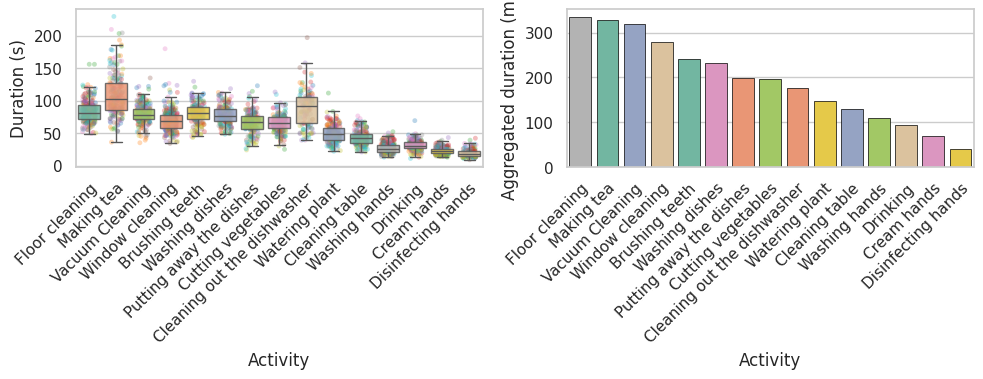

In [17]:
order = (act_df.groupby("Activity")["Duration"]
           .sum()
           .sort_values(ascending=False)
           .index)

fig, axes = plt.subplots(1,2, figsize=(10, 4))


sns.stripplot(data=act_df, x="Activity", y="Duration",
              order=order, palette="tab10",
              dodge=False, jitter=0.25, size=3.5, alpha=0.3, legend=False, ax=axes[0],
              hue="Participant", zorder=1)
sns.boxplot(data=act_df, x="Activity", y="Duration", hue="Activity", palette="Set2", showfliers=False, ax=axes[0], zorder=2, boxprops=dict(alpha=0.85, linewidth=1))

sns.barplot(data=act_df.groupby("Activity").sum(numeric_only=True) / 60, x="Activity", y="Duration", order=order, palette="Set2", hue="Activity", ax=axes[1],linewidth=0.5, edgecolor="black")
for label in axes[0].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')
    label.set_rotation_mode("anchor")
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
axes[0].set_ylabel("Duration (s)")
axes[1].set_ylabel("Aggregated duration (min)")
plt.tight_layout()
plt.savefig("activity_durations.pdf")
plt.show()

#### Example data plots

In [19]:
def extract_log_mel_spectrogram_sliding_window(audio_data, sr=44100, window_size=2, hop_size=2, n_mels=128, n_fft=2048, hop_length=None, labels_df=None, normalize=False):
    """
    Computes log-Mel spectrogram features using a sliding window approach.
    
    Parameters:
        - audio_data: 1D numpy array of raw audio
        - sr: Sampling rate
        - window_size: Duration of each window in seconds
        - hop_size: Hop size between windows in seconds
        - n_mels: Number of Mel bands
        - n_fft: FFT window size
        - hop_length: STFT hop length (in samples); defaults to 1/4 of n_fft
    
    Returns:
        - A 3D numpy array of shape (num_windows, n_mels, num_frames_per_window)
    """
    win_length = int(window_size * sr)
    hop_samples = int(hop_size * sr)
    hop_length = hop_length or n_fft // 4
    num_windows = (len(audio_data) - win_length) // hop_samples + 1

    segments = []

    for i in range(num_windows):
        start = i * hop_samples
        end = start + win_length
        y_win = audio_data[start:end]

        # Compute Mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y_win,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            power=2.0  # Power spectrogram (amplitude squared)
        )

        # Convert to log scale (dB)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

        segments.append(log_mel_spec)

            
    labels = np.zeros(len(segments))
        
    if labels_df is not None:
        for _, line in labels_df.iterrows():
            if (line.stop_sample - line.start_sample) / sr < 2:
                continue
            start = (line.start_sample - win_length + hop_samples) // hop_samples
            stop = (line.stop_sample - win_length + hop_samples) // hop_samples
            labels[start:stop] = 1

    segments = np.array(segments)
    

    return segments, labels # Shape: (num_windows, n_mels, frames_per_window)

In [27]:
targets = ["04", "07"]
rec_targets = ["0402", "0702"]
act_targets = ["Brushing teeth", "Washing hands"]

In [28]:
# sr = 44100  # 44.1kHz audio files!

audios = []
lefts = []
rights = []
humids = []

for j, part_path in enumerate(tqdm(get_participants(base_path))):
    recordings = get_recordings(part_path)
    part = part_path[-2:] 
    if part not in targets:
        continue
    for recording in recordings:
        if recording[-4:] not in rec_targets:
            continue
        try:
            print(f"recording: {recording}")
            label_df = get_labels(recording)
            label_df["ts_sync"] = (label_df.Time - label_df.Time.iloc[0]) * 1000
            
            all_labels = label_df.Description.iloc[1:].unique()
            af = get_audio(recording)
            ad = af["audio"]
            ad = np.array(ad).astype(np.float32) / 32768.0

            df = pd.read_csv(get_puck(recording))
            df2 = pd.read_csv(get_watch(recording))
            
            for label in act_targets:
                l_df = label_df[label_df.Description == label]
                l_start = l_df[l_df.Type == "start"]
                l_stop = l_df[l_df.Type == "end"]

                acts = list(zip(l_start.ts_sync.to_list(), l_stop.ts_sync.to_list()))
                
                for i, (start, stop) in enumerate(acts):
                    if i == 2:
                        break
                    length = int((stop-start) / 1000)
                    start_samples = int(start * 44.1)
                    stop_samples = int(stop * 44.1)
                    spt = extract_log_mel_spectrogram_sliding_window(ad[start_samples:stop_samples], sr=44100, window_size=length, hop_size=length)[0][0]             
                    audios.append(spt)
                    lefts.append(df[(df.ts_sync>start)&(df.ts_sync<stop)][["acc_" + x for x in "xyz"]])
                    rights.append(df2[(df2.ts_sync>start)&(df2.ts_sync<stop)][["acc_" + x for x in "xyz"]])
                    humids.append(df[(df.ts_sync>start)&(df.ts_sync<stop)]["humid"])

                    #axes[3,0].set_title("humidity")
                    

        
        except Exception as e:
            print(f"recording: {recording} failed:", e)
            raise(Exception())

  0%|          | 0/20 [00:00<?, ?it/s]

recording: AudioDS/Dataset/Records/04/0402
recording: AudioDS/Dataset/Records/07/0702


0 Log
-Mel y: -128.0 x 129.2
1 Left
Acc. y: 25466.1 x 79.64
2 Right
Acc. y: 38.1828491 x 75.32
3 Hum. y: 4.808203125000006 x 79.64
4  y: -128.0 x 144.72
5  y: 27364.7 x 89.06
6  y: 51.168260000000004 x 84.82
7  y: 4.525683593750003 x 89.06
8 Log
-Mel y: -128.0 x 111.98
9 Left
Acc. y: 25061.3 x 68.98
10 Right
Acc. y: 32.9575939 x 65.1
11 Hum. y: 4.932812499999997 x 68.98
12  y: -128.0 x 156.78
13  y: 29629.6 x 96.6
14  y: 43.76910615 x 91.22
15  y: 13.679101562499994 x 96.6
16 Log
-Mel y: -128.0 x 46.52
17 Left
Acc. y: 48136.0 x 28.66
18 Right
Acc. y: 55.0931315 x 27.24
19 Hum. y: 12.439453125 x 28.66
20  y: -128.0 x 60.3
21  y: 24922.7 x 37.08
22  y: 37.736215 x 35.56
23  y: 8.013671875 x 37.08
24 Log
-Mel y: -128.0 x 55.14
25 Left
Acc. y: 30888.0 x 34.0
26 Right
Acc. y: 44.898216000000005 x 32.48
27 Hum. y: 15.361328125 x 34.0
28  y: -128.0 x 43.08
29  y: 28758.4 x 26.66
30  y: 26.2461793 x 25.24
31  y: 16.400097656250004 x 26.66


/tmp/ipykernel_31525/1854727788.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


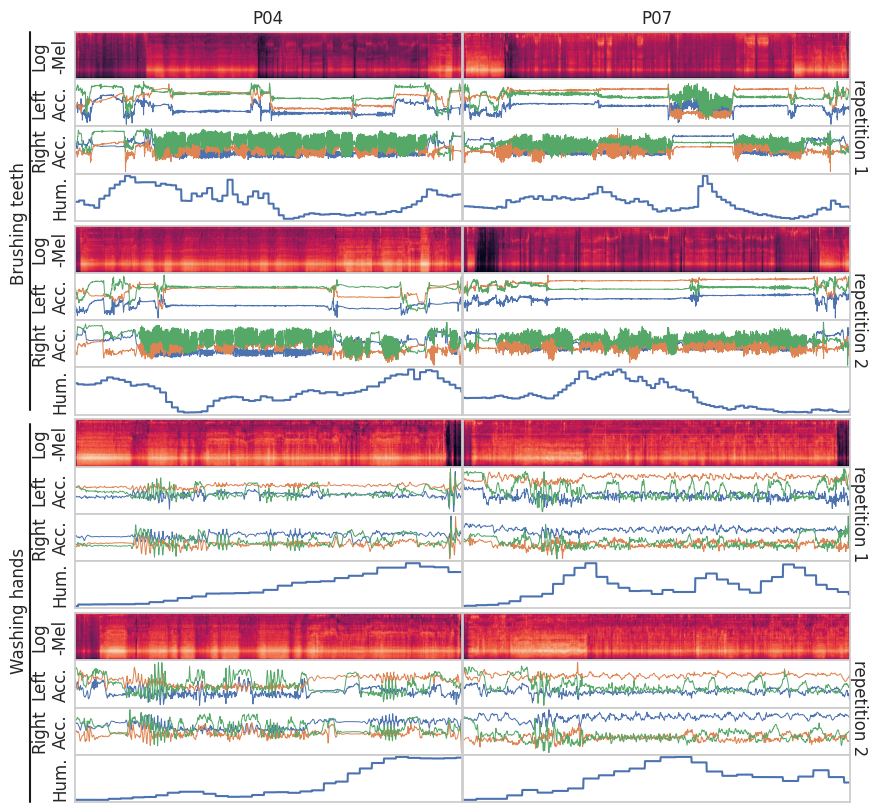

In [29]:
fig = plt.figure(figsize=(10, 10))
outer = fig.add_gridspec(4, 2, hspace=0.025, wspace=0.005)

axes_groups = []

for i in range(4):
    for j in range(2):
        inner = outer[i, j].subgridspec(4, 1, hspace=0.0)

        group_axes = []
        for k in range(4):
            ax = fig.add_subplot(inner[k])  # <- create subplot
            group_axes.append(ax)

        axes_groups.append(group_axes)

order = [0,2,4,6,1,3,5,7]
for i, ad, l, r, h in zip(order, audios, lefts, rights, humids):
    axes_groups[i][0].imshow(ad, aspect="auto")
    axes_groups[i][0].grid(False)
    l.plot(ax=axes_groups[i][1], legend=False, lw=0.7)
    axes_groups[i][1].set_xlim(l.index[0], l.index[-1])
    r.plot(ax=axes_groups[i][2], legend=False, lw=0.7)
    axes_groups[i][2].set_xlim(r.index[0], r.index[-1])
    h.plot(ax=axes_groups[i][3])
    axes_groups[i][3].set_xlim(h.index[0], h.index[-1])
for i, ax in enumerate(fig.axes):
    ax.set_xticks([])
    ax.set_yticks([])
    if (i+1) % 4 == 0 and (i+1) % 8 != 0:
        ax.set_ylabel("Hum.")
    if (i+2) % 4 == 0 and (i+2) % 8 != 0:
        ax.set_ylabel("Right\nAcc.")
    if (i+3) % 4 == 0 and (i+3) % 8 != 0:
        ax.set_ylabel("Left\nAcc.")
    if i % 4 == 0 and i % 8 == 0:
        ax.set_ylabel("Log\n-Mel")


    ys = ax.get_ylim()
    y_dist = ys[1]-ys[0]

    
    xs = ax.get_xlim()
    x_dist = xs[1]-xs[0]
    print(i, ax.get_ylabel(), "y:", y_dist, "x", x_dist / 50)

axes_groups[0][0].set_title("P" + targets[0])
axes_groups[1][0].set_title("P07")

# Upper group (rows 0–1)
top_group = axes_groups[0][1].get_position()
y_top = (top_group.y0 + axes_groups[2][2].get_position().y1) / 2
y_bottom = (axes_groups[4][1].get_position().y0 + axes_groups[6][2].get_position().y1) / 2



x = 0.06

fig.text(x , y_top, act_targets[0], rotation=90, va="center")
fig.text(x, y_bottom, act_targets[1], rotation=90, va="center")

# get top and bottom y positions of the rows you want to hug
top_ax = axes_groups[0][0]      # top of first row
bottom_ax = axes_groups[1][0]   # bottom of second row

y_top = top_ax.get_position().y1
y_bottom = bottom_ax.get_position().y0
  # figure coordinate, slightly left of the axes

fig.lines.extend([plt.Line2D([x + 0.02, x + 0.02], [axes_groups[2][3].get_position().y0 + 0.005, axes_groups[0][0].get_position().y1], transform=fig.transFigure, color='k', lw=1.5)])
fig.lines.extend([plt.Line2D([x + 0.02, x + 0.02], [axes_groups[6][3].get_position().y0 , axes_groups[4][0].get_position().y1 - 0.005], transform=fig.transFigure, color='k', lw=1.5)])

fig.text(0.9, axes_groups[1][2].get_position().y1, "repetition 1", rotation=270, va="center")
fig.text(0.9, axes_groups[3][2].get_position().y1, "repetition 2", rotation=270, va="center")
fig.text(0.9, axes_groups[5][2].get_position().y1, "repetition 1", rotation=270, va="center")
fig.text(0.9, axes_groups[7][2].get_position().y1, "repetition 2", rotation=270, va="center")

plt.tight_layout()
plt.savefig("large_comparison.pdf", bbox_inches="tight")

#### All dataset visualization:

In [30]:
def visualize(pp, df, df2, ad, label_df):
    all_labels = label_df.Description.iloc[1:].unique()

    for label in all_labels:
        l_df = label_df[label_df.Description == label]
        l_start = l_df[l_df.Type == "start"]
        l_stop = l_df[l_df.Type == "end"]
        
        for i, (start, stop) in enumerate(zip(l_start.ts_sync.to_list(), l_stop.ts_sync.to_list())):
            length = int((stop-start) / 1000)
            start_samples = int(start * 44.1)
            stop_samples = int(stop * 44.1)
            spt = extract_log_mel_spectrogram_sliding_window(ad[start_samples:stop_samples], sr=44100, window_size=length, hop_size=length)[0][0]

            fig, axes = plt.subplots(4, 1, figsize=(8,10), )   # gridspec_kw={'width_ratios': [2, 1]}
            axes[0].imshow(spt, aspect="auto")           
            try:
                axes[1].plot(df[(df.ts_sync>start)&(df.ts_sync<stop)][["acc_" + x for x in "xyz"]])
                axes[1].set_title("left hand")
                axes[1].set_xlim(df[(df.ts_sync>start)&(df.ts_sync<stop)][["acc_" + x for x in "xyz"]].index[0],df[(df.ts_sync>start)&(df.ts_sync<stop)][["acc_" + x for x in "xyz"]].index[-1])
                axes[3].plot(df[(df.ts_sync>start)&(df.ts_sync<stop)]["humid"])
                axes[3].set_title("humidity")
                axes[3].set_xlim(df[(df.ts_sync>start)&(df.ts_sync<stop)]["humid"].index[0], df[(df.ts_sync>start)&(df.ts_sync<stop)]["humid"].index[-1])
            except:
                print("puck data error")
            axes[2].plot(df2[(df2.ts_sync>start)&(df2.ts_sync<stop)][["acc_" + x for x in "xyz"]])
            axes[2].set_title("right hand")
            axes[2].set_xlim(df2[(df2.ts_sync>start)&(df2.ts_sync<stop)][["acc_" + x for x in "xyz"]].index[0], df2[(df2.ts_sync>start)&(df2.ts_sync<stop)][["acc_" + x for x in "xyz"]].index[-1])
            
            plt.suptitle(f"{recording}: {label} {i+1}:")
            plt.tight_layout()
    
    
            pp.savefig(fig)
            plt.close()

In [43]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

def load_one_recording(recording, resample=True):
    label_df = get_labels(recording)
    label_df = clean_label_df(label_df)
    
    df = pd.read_csv(get_puck(recording))
    if resample:
        df["time"] = pd.to_timedelta(df["ts_sync"], unit="ms")
        df = df.set_index("time")
        df = (
            df.select_dtypes(include="number")
              .resample("20ms")
              .mean()
              .interpolate()
        )
        df[feature_cols] = scaler.fit_transform(df[feature_cols])
    
    df2 = pd.read_csv(get_watch(recording))
    if resample:
        df2["time"] = pd.to_timedelta(df2["ts_sync"], unit="ms")
        df2 = df2.set_index("time")
        df2 = (
            df2.select_dtypes(include="number")
              .resample("20ms")
              .mean()
              .interpolate()
        )
        df2[feature_cols] = scaler.fit_transform(df2[feature_cols])

    af = get_audio(recording)
    ad = af["audio"]
    ad = np.array(ad).astype(np.float32) / 32768.0

    return df, df2, ad, label_df


def clean_label_df(label_df):
    label_df["ts_sync"] = (label_df.Time - label_df.Time.iloc[0]) * 1000
    label_df = label_df[~label_df["Description"].str.contains("deleted", na=False)]
    label_df = label_df.iloc[1:]
    return label_df
    

def handle_split_recordings(rec1, rec2, resample=True):
    label_df1 = get_labels(rec1)
    label_df1 = clean_label_df(label_df1)
    label_df2 = get_labels(rec2)
    task_list = pd.read_csv(glob(rec1 + "/*TASKLIST.csv")[0])
    
    # Find the checkpoint, at which the split happened, by looking at the first 4 entries of the second recording's labels
    seq = label_df2[label_df2.Type=="end"].Description.to_list()[:4]
    tl = task_list.TASKS.to_list()
    ind = [i for i in range(len(tl)) if tl[i:i+len(seq)] == seq][0]
    
    # The last recording should end with these 5 (which were conducted before the checkpoint)
    end_seq = tl[ind-5:ind-1]
    labels_1 = label_df1[label_df1.Type=="end"].Description.to_list()
    indices = label_df1[label_df1.Type=="end"].index
    # Match the sequence to an index
    ind = [i + len(end_seq) - 1 for i in range(len(labels_1)) if labels_1[i:i+len(end_seq)] == end_seq][0]

    # calculate timestamp for end of first recording.
    last_line1 = label_df1.loc[indices[ind]]
    last_ts = last_line1.ts_sync + 1000

    df1, df2, ad, label_df = load_one_recording(rec1, resample=resample)
    df1 = df1[df1.ts_sync < last_ts]
    df2 = df2[df2.ts_sync < last_ts]
    ad = ad[:int(44100 * last_ts / 1000)]
    label_df = label_df[label_df.ts_sync < last_ts]
    return (df1, df2, ad, label_df), load_one_recording(rec2, resample=resample)
    
    
    

In [ ]:
sr = 44100  # 44.1kHz audio files!

for j, part_path in enumerate(tqdm(get_participants(base_path))):
    part = part_path[-2:]
    recordings = get_recordings(part_path)
    viz_path = f"viz/viz_{part}.pdf"
    os.makedirs("viz", exist_ok=True)
    if os.path.isfile(viz_path) and not os.path.getsize(viz_path) < 25 * 1e6:  #files should have over 30MB
        print(viz_path, "already exists, skipping...")
        continue
    pp = PdfPages(viz_path)
    for recording in recordings:
        try:
            print(f"recording: {recording}")
            try:
                label_df = get_labels(recording)
                label_df["ts_sync"] = (label_df.Time - label_df.Time.iloc[0]) * 1000
                df, df2, ad, label_df = load_one_recording(recording, resample=False)
            except Exception as e:
                print(f"recording: {recording}:", e)
                rec1 = recording + "/" + recording[-4:] + "01"
                rec2 = recording + "/" + recording[-4:] + "02"
                print("recordings: ", rec1, rec2)
                r1, r2 = handle_split_recordings(rec1, rec2, resample=False)
                for df, df2, ad, label_df in [r1, r2]:
                    visualize(pp, df, df2, ad, label_df)
                print("split data combined successfully")
                continue
            visualize(pp, df, df2, ad, label_df)
            

        except Exception as e:
            print(f"recording: {recording} failed:", e)
            pp.close()
            raise(Exception())
    pp.close()

  0%|          | 0/20 [00:00<?, ?it/s]

recording: AudioDS/Dataset/Records/02/0202
recording: AudioDS/Dataset/Records/02/0203
recording: AudioDS/Dataset/Records/02/0204
recording: AudioDS/Dataset/Records/02/0201
recording: AudioDS/Dataset/Records/05/0504
recording: AudioDS/Dataset/Records/05/0501
AudioDS/Dataset/Records/05/0501
recording: AudioDS/Dataset/Records/05/0501: 
recordings:  AudioDS/Dataset/Records/05/0501/050101 AudioDS/Dataset/Records/05/0501/050102
split data combined successfully
recording: AudioDS/Dataset/Records/05/0502
recording: AudioDS/Dataset/Records/05/0503
recording: AudioDS/Dataset/Records/08/0803


### Participant Description

In [ ]:
from io import StringIO

data = """ Participant,01,02,03,04,05,06,07,08,09,10,11,12,13,14,15,16,17,18,19,20
Age,37,36,34,67,46,47,20,18,51,18,33,62,65,28,33,26,43,32,35,24
Gender,m,f,f,f,f,m,m,f,f,m,m,m,m,m,m,m,f,f,f,f
Handedness,R,R,R,R,R,R,L,R,R,L,R,R,R,L,R,R,R,R,R,R
"""

df = pd.read_csv(StringIO(data))
df = df.T.reset_index()
df.columns = df.iloc[0]
df = df.iloc[1:]
df